In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Load data
df = pd.read_csv("creditcard.csv")

# 2. Select V1-V28 features AND the Amount feature (29 dimensions in total)
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[feature_cols].values
y = df['Class'].values

# 3. Apply standard scaling to all 29 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform a stratified Train/Test split FIRST to prevent any data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Separate real training minority (fraud) and majority (legit) samples
X_train_fraud = X_train[y_train == 1]
X_train_legit = X_train[y_train == 0]

print("Training Fraud transactions shape:", X_train_fraud.shape)   # Expected: (344, 29)
print("Training Legit transactions shape:", X_train_legit.shape)   # Expected: (199020, 29)
print("Testing set features shape:", X_test.shape)                 # Expected: (85443, 29)

Training Fraud transactions shape: (344, 29)
Training Legit transactions shape: (199020, 29)
Testing set features shape: (85443, 29)


Signal vector s (29 dimensions):
[ -1.093   2.486  -5.934   2.845  -3.718  -3.118  -7.566   1.609  -3.665
 -12.574   8.911 -14.179  -0.141 -18.382   1.62  -15.129 -25.521  -9.334
   3.679   2.238   2.524  -0.228  -0.544   0.489   2.617  -1.076   5.828
   3.425  -0.35 ]


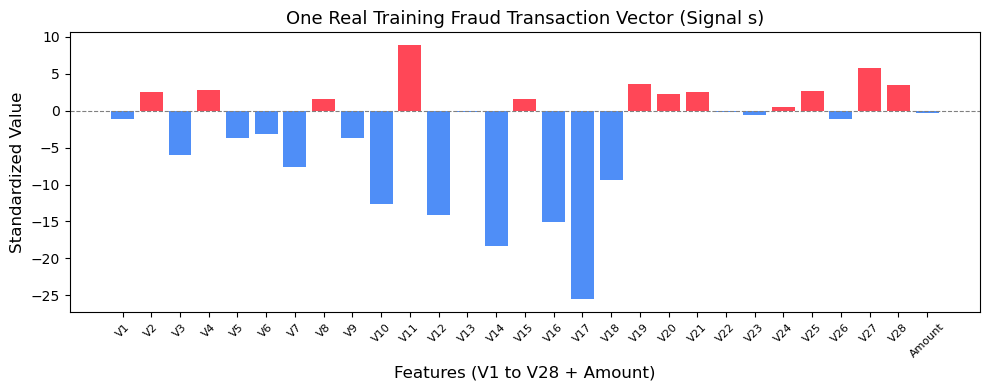

In [2]:
# Grab the first training fraud transaction as our example signal s
s = X_train_fraud[0]

print("Signal vector s (29 dimensions):")
print(s.round(3))

# Visualize it
plt.figure(figsize=(10, 4))
plt.bar(range(len(s)), s, color=['#ff4757' if v > 0 else '#4f8ef7' for v in s])
plt.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Features (V1 to V28 + Amount)', fontsize=12)
plt.ylabel('Standardized Value', fontsize=12)
plt.title('One Real Training Fraud Transaction Vector (Signal s)', fontsize=13)

# Update x-ticks to reflect 29 features
plt.xticks(range(29), [f'V{i+1}' for i in range(28)] + ['Amount'], rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

In [3]:
# Apply Discrete Fourier Transform
spectrum = np.fft.fft(s)

print("Spectrum output (complex numbers):")
print(spectrum.round(3))
print("\nSpectrum data type:", spectrum.dtype)

Spectrum output (complex numbers):
[-84.279 +0.j     69.316+33.163j -38.688+13.018j  36.37 -10.235j
 -24.27 +27.944j  -9.697-28.554j  13.615+22.54j  -36.448-12.953j
  38.164+14.708j -10.766-32.892j  12.931-18.584j -15.241+18.058j
  45.731-13.646j -46.574-33.333j  -8.149+45.026j  -8.149-45.026j
 -46.574+33.333j  45.731+13.646j -15.241-18.058j  12.931+18.584j
 -10.766+32.892j  38.164-14.708j -36.448+12.953j  13.615-22.54j
  -9.697+28.554j -24.27 -27.944j  36.37 +10.235j -38.688-13.018j
  69.316-33.163j]

Spectrum data type: complex128


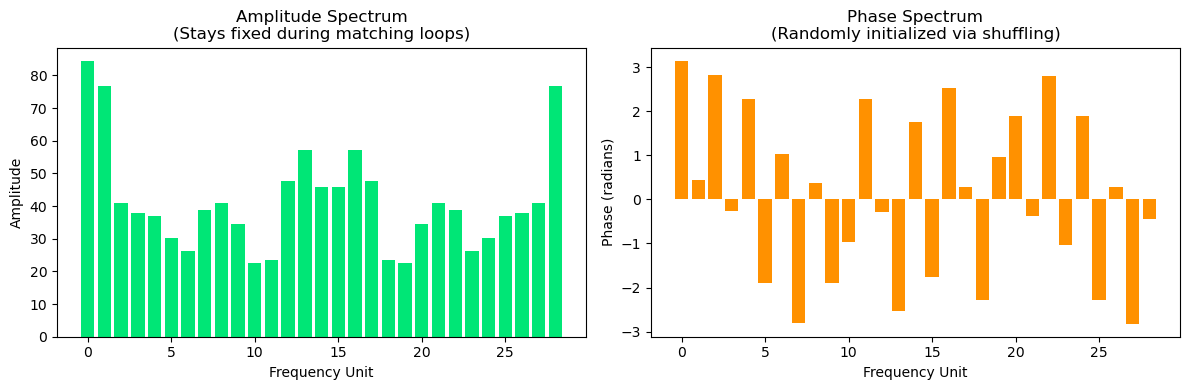

In [4]:
amplitude = np.abs(spectrum)
phase = np.angle(spectrum)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(amplitude)), amplitude, color='#00e676')
axes[0].set_title('Amplitude Spectrum\n(Stays fixed during matching loops)', fontsize=12)
axes[0].set_xlabel('Frequency Unit')
axes[0].set_ylabel('Amplitude')

axes[1].bar(range(len(phase)), phase, color='#ff9100')
axes[1].set_title('Phase Spectrum\n(Randomly initialized via shuffling)', fontsize=12)
axes[1].set_xlabel('Frequency Unit')
axes[1].set_ylabel('Phase (radians)')

plt.tight_layout()
plt.show()

In [5]:
def iaaft_s(s, n_iterations=50):
    """
    Generates a realistic synthetic surrogate sequence for a given transaction.
    Uses time-domain shuffling to ensure perfect conjugate symmetry.
    """
    # 1. Compute original target amplitude profile
    original_spectrum = np.fft.fft(s)
    original_amplitude = np.abs(original_spectrum)
    sorted_s = np.sort(s)
    
    # 2. Correct Phase Initialization: Shuffle signal values directly in time-domain
    shuffled_init = np.random.permutation(s)
    
    # 3. Extract phase spectrum from this real-valued shuffled configuration
    init_phase = np.angle(np.fft.fft(shuffled_init))
    
    # 4. Construct first iterative spectrum and return to time domain
    init_spectrum = original_amplitude * np.exp(1j * init_phase)
    current = np.fft.ifft(init_spectrum).real
    
    # 5. Rank-order amplitude matching (shuffling correction)
    current = sorted_s[np.argsort(np.argsort(current))]
    
    # 6. Amplitude-Phase refinement loops
    for i in range(n_iterations):
        previous = current.copy()
        
        current_spectrum = np.fft.fft(current)
        current_phase = np.angle(current_spectrum)
        
        # Enforce target amplitude while keeping phase
        new_spectrum = original_amplitude * np.exp(1j * current_phase)
        current = np.fft.ifft(new_spectrum).real
        
        # Enforce exact empirical values
        current = sorted_s[np.argsort(np.argsort(current))]
        
        # Stop early if sequence stops morphing
        if np.max(np.abs(current - previous)) < 1e-6:
            break
            
    return current

In [6]:
print(f"Generating synthetic surrogates for {len(X_train_fraud)} training fraud records...")

synthetic_frauds = []
for i, fraud_sample in enumerate(X_train_fraud):
    surrogate = iaaft_s(fraud_sample, n_iterations=50)
    synthetic_frauds.append(surrogate)

synthetic_frauds = np.array(synthetic_frauds)

# Combine original training samples with the generated synthetic profiles
X_train_augmented = np.vstack([X_train, synthetic_frauds])
y_train_augmented = np.concatenate([y_train, np.ones(len(synthetic_frauds))])

print("\n--- DATASET BALANCING COMPLETED ---")
print("Original Training Feature Shape: ", X_train.shape)
print("Augmented Training Feature Shape:", X_train_augmented.shape)

Generating synthetic surrogates for 344 training fraud records...

--- DATASET BALANCING COMPLETED ---
Original Training Feature Shape:  (199364, 29)
Augmented Training Feature Shape: (199708, 29)


In [7]:
print(f"{'Statistical Metric':<25} {'Original Train Fraud':>22} {'Synthetic Surrogates':>22}")
print("-" * 75)
print(f"{'Mean Value':<25} {X_train_fraud.mean():>22.4f} {synthetic_frauds.mean():>22.4f}")
print(f"{'Standard Deviation':<25} {X_train_fraud.std():>22.4f} {synthetic_frauds.std():>22.4f}")
print(f"{'Minimum Element':<25} {X_train_fraud.min():>22.4f} {synthetic_frauds.min():>22.4f}")
print(f"{'Maximum Element':<25} {X_train_fraud.max():>22.4f} {synthetic_frauds.max():>22.4f}")

Statistical Metric          Original Train Fraud   Synthetic Surrogates
---------------------------------------------------------------------------
Mean Value                               -1.3635                -1.3635
Standard Deviation                        4.6730                 4.6730
Minimum Element                         -35.2094               -35.2094
Maximum Element                          37.0347                37.0347


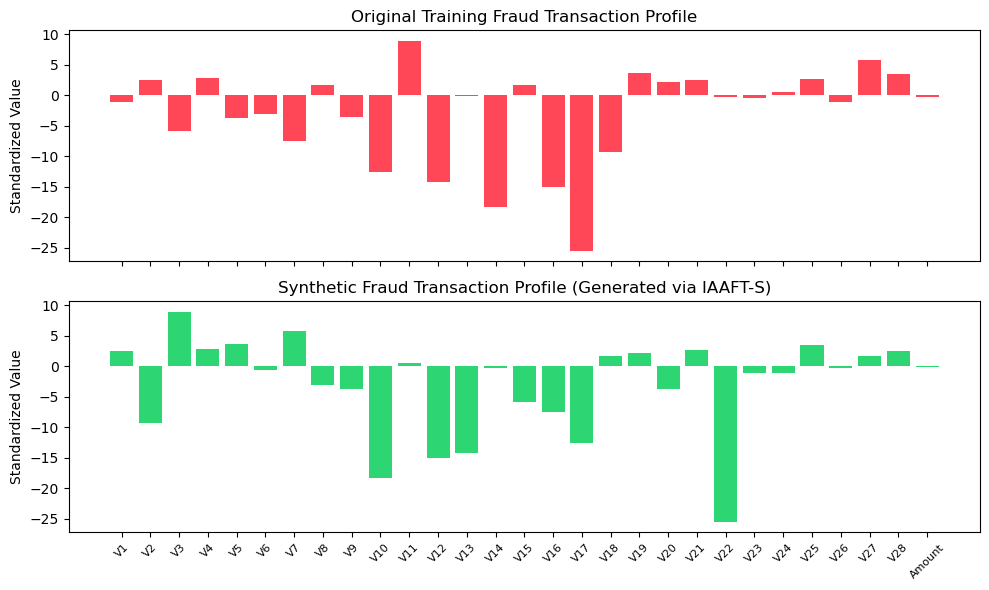

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot Original
axes[0].bar(range(29), X_train_fraud[0], color='#ff4757')
axes[0].set_title('Original Training Fraud Transaction Profile')
axes[0].set_ylabel('Standardized Value')

# Plot Synthetic
axes[1].bar(range(29), synthetic_frauds[0], color='#2ed573')
axes[1].set_title('Synthetic Fraud Transaction Profile (Generated via IAAFT-S)')
axes[1].set_ylabel('Standardized Value')

plt.xticks(range(29), [f'V{i+1}' for i in range(28)] + ['Amount'], rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
print("Training the Baseline Model (Imbalanced Real Data Only)...")
model_baseline = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
model_baseline.fit(X_train, y_train)

print("Training the Augmented Model (Real Data + IAAFT-S Synthetic Surrogates)...")
model_augmented = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
model_augmented.fit(X_train_augmented, y_train_augmented)

# Get predictions
y_pred_base = model_baseline.predict(X_test)
y_prob_base = model_baseline.predict_proba(X_test)[:, 1]

y_pred_aug = model_augmented.predict(X_test)
y_prob_aug = model_augmented.predict_proba(X_test)[:, 1]

# Display evaluation classification reports
print("\n================== BASELINE MODEL PERFORMANCE ==================")
print(classification_report(y_test, y_pred_base))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_base):.4f}")

print("\n================== AUGMENTED MODEL PERFORMANCE ==================")
print(classification_report(y_test, y_pred_aug))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_aug):.4f}")

Training the Baseline Model (Imbalanced Real Data Only)...
Training the Augmented Model (Real Data + IAAFT-S Synthetic Surrogates)...

================== BASELINE MODEL PERFORMANCE ==================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC Score: 0.9341

================== AUGMENTED MODEL PERFORMANCE ==================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.91      0.78      0.84       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC Score: 0.9334


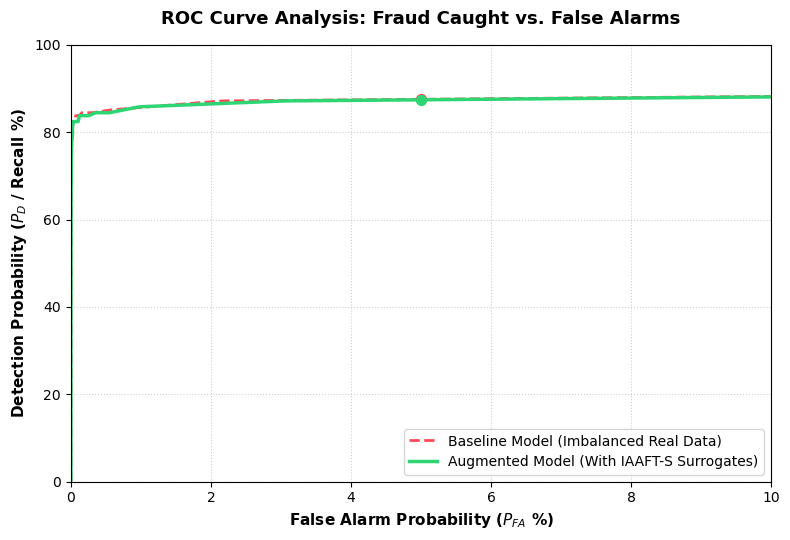

                  GRAPH SUMMARY & INTERPRETATION                       
This graph illustrates the business trade-off between catching fraud
and accidentally bothering legitimate customers (False Alarms).
----------------------------------------------------------------------
At a strict 1% False Alarm Rate (allowing only 1% mistakes):
  • Baseline Model catches   : 85.67% of all fraud transactions
  • IAAFT-S Augmented catches: 85.83% of all fraud transactions
  • Net Change               : +0.16% fraud caught
----------------------------------------------------------------------
At a standard 5% False Alarm Rate (the paper's benchmark operational point):
  • Baseline Model catches   : 87.54% of all fraud transactions
  • IAAFT-S Augmented catches: 87.42% of all fraud transactions
  • Net Change               : -0.12% fraud caught


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 1. Calculate the raw ROC data points
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_aug, tpr_aug, _ = roc_curve(y_test, y_prob_aug)

# Convert to percentages for business presentation
fpr_base_pct = fpr_base * 100
tpr_base_pct = tpr_base * 100
fpr_aug_pct = fpr_aug * 100
tpr_aug_pct = tpr_aug * 100

# 2. Extract exact evaluation points (e.g., at 1% and 5% False Alarm Rates)
# This calculates exactly what value the curve hits at those operational thresholds
base_pd_at_1 = np.interp(1.0, fpr_base_pct, tpr_base_pct)
aug_pd_at_1 = np.interp(1.0, fpr_aug_pct, tpr_aug_pct)

base_pd_at_5 = np.interp(5.0, fpr_base_pct, tpr_base_pct)
aug_pd_at_5 = np.interp(5.0, fpr_aug_pct, tpr_aug_pct)

# 3. Create the Visual Plot
plt.figure(figsize=(8, 5.5))
plt.plot(fpr_base_pct, tpr_base_pct, label='Baseline Model (Imbalanced Real Data)', linestyle='--', color='#ff4757', linewidth=2)
plt.plot(fpr_aug_pct, tpr_aug_pct, label='Augmented Model (With IAAFT-S Surrogates)', color='#2ed573', linewidth=2.5)

# Add highlight markers at the 5% False Alarm operating point
plt.scatter([5.0], [base_pd_at_5], color='#ff4757', s=50, zorder=5)
plt.scatter([5.0], [aug_pd_at_5], color='#2ed573', s=50, zorder=5)

# Adjusted axes: Zoomed into 0-10% False Alarm Rate, allowing full 0-100% Detection visibility
plt.xlim(0, 10)
plt.ylim(0, 100)

plt.xlabel('False Alarm Probability ($P_{FA}$ %)', fontsize=11, fontweight='bold')
plt.ylabel('Detection Probability ($P_D$ / Recall %)', fontsize=11, fontweight='bold')
plt.title('ROC Curve Analysis: Fraud Caught vs. False Alarms', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Print Clear Explanatory Metrics Directly Under the Graph
print("=" * 70)
print("                  GRAPH SUMMARY & INTERPRETATION                       ")
print("=" * 70)
print("This graph illustrates the business trade-off between catching fraud")
print("and accidentally bothering legitimate customers (False Alarms).")
print("-" * 70)
print(f"At a strict 1% False Alarm Rate (allowing only 1% mistakes):")
print(f"  • Baseline Model catches   : {base_pd_at_1:.2f}% of all fraud transactions")
print(f"  • IAAFT-S Augmented catches: {aug_pd_at_1:.2f}% of all fraud transactions")
print(f"  • Net Change               : {aug_pd_at_1 - base_pd_at_1:+.2f}% fraud caught")
print("-" * 70)
print(f"At a standard 5% False Alarm Rate (the paper's benchmark operational point):")
print(f"  • Baseline Model catches   : {base_pd_at_5:.2f}% of all fraud transactions")
print(f"  • IAAFT-S Augmented catches: {aug_pd_at_5:.2f}% of all fraud transactions")
print(f"  • Net Change               : {aug_pd_at_5 - base_pd_at_5:+.2f}% fraud caught")
print("======================================================================")